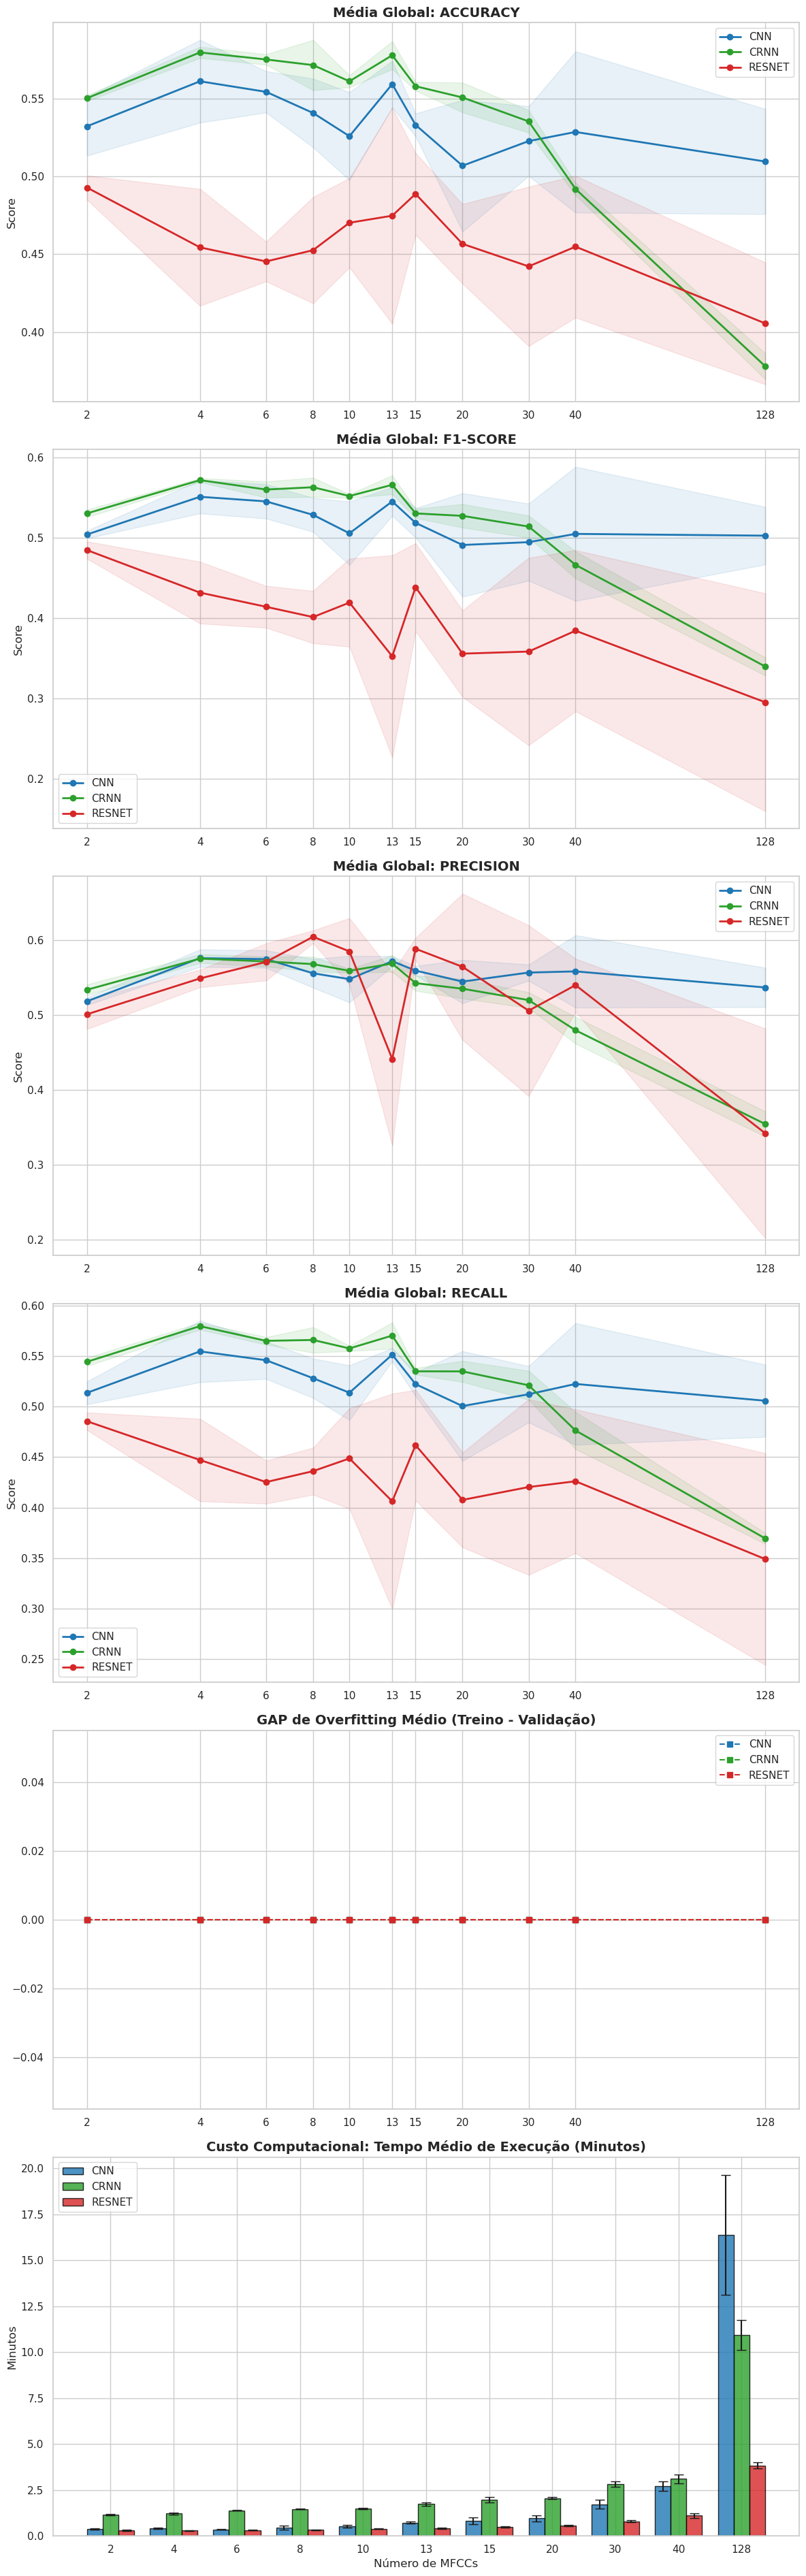

In [7]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns

if os.path.basename(os.getcwd()) == 'Core':
    os.chdir('../../')

sns.set_theme(style="whitegrid")

def extrair_dados():
    res_base_path = "../resultados"
    modelos = ["CNN", "CRNN", "RESNET"]
    sementes = [42, 123, 999]
    
    pastas = sorted([int(d.split('_')[-1]) for d in os.listdir(res_base_path) if d.startswith("n_mfccs_")])
    
    val_data = {m: {met: {n: [] for n in pastas} for met in ["accuracy", "f1-score", "precision", "recall"]} for m in modelos}
    gap_data = {m: {n: [] for n in pastas} for m in modelos}
    tempo_data = {m: {n: [] for n in pastas} for m in modelos}

    for n in pastas:
        for m in modelos:
            for s in sementes:
                path = os.path.join(res_base_path, f"n_mfccs_{n}", f"seed_{s}", f"{m}_history.pkl")
                if os.path.exists(path):
                    with open(path, 'rb') as f:
                        h = pickle.load(f)
                        val_data[m]["accuracy"][n].append(h.get('val_accuracy', h.get('val_acc', 0)))
                        
                        report = h.get('classification_report', {})
                        if isinstance(report, dict) and 'macro avg' in report:
                            val_data[m]["f1-score"][n].append(report['macro avg']['f1-score'])
                            val_data[m]["precision"][n].append(report['macro avg']['precision'])
                            val_data[m]["recall"][n].append(report['macro avg']['recall'])
                        
                        t_acc = h.get('accuracy', h.get('acc', [0]))[-1] if isinstance(h.get('accuracy'), list) else h.get('accuracy', 0)
                        v_acc = h.get('val_accuracy', h.get('val_acc', [0]))[-1] if isinstance(h.get('val_accuracy'), list) else h.get('val_accuracy', 0)
                        gap_data[m][n].append(t_acc - v_acc)

    tempo_path = os.path.join(res_base_path, "tempos_execucao.pkl")
    if os.path.exists(tempo_path):
        with open(tempo_path, 'rb') as f:
            t_dict = pickle.load(f)
            for m in modelos:
                if m in t_dict:
                    for n in pastas:
                        if n in t_dict[m]:
                            tempo_data[m][n] = list(t_dict[m][n].values())

    return val_data, gap_data, tempo_data, pastas, modelos

def plotar_benchmark(val_data, gap_data, tempo_data, pastas, modelos):
    fig, axes = plt.subplots(6, 1, figsize=(12, 38))
    cores = {"CNN": "#1f77b4", "CRNN": "#2ca02c", "RESNET": "#d62728"}
    
    # Gráficoss: Métricas de Validação
    metrics = ["accuracy", "f1-score", "precision", "recall"]
    for idx, met in enumerate(metrics):
        ax = axes[idx]
        for m in modelos:
            vals = [val_data[m][met][n] for n in pastas]
            medias = [np.mean(v) if v else 0 for v in vals]
            stds = [np.std(v) if v else 0 for v in vals]
            
            ax.plot(pastas, medias, label=m, color=cores[m], marker='o', linewidth=2)
            ax.fill_between(pastas, np.array(medias) - np.array(stds), 
                            np.array(medias) + np.array(stds), color=cores[m], alpha=0.1)
        
        ax.set_title(f"Média Global: {met.upper()}", fontweight='bold', fontsize=14)
        ax.set_xscale('log', base=2); ax.set_xticks(pastas)
        ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
        ax.set_ylabel("Score")
        ax.legend()

    # Gráfico: Gap de Overfitting
    ax_gap = axes[4]
    for m in modelos:
        medias_gap = [np.mean(gap_data[m][n]) if gap_data[m][n] else 0 for n in pastas]
        ax_gap.plot(pastas, medias_gap, label=m, color=cores[m], linestyle='--', marker='s')
    ax_gap.set_title("GAP de Overfitting Médio (Treino - Validação)", fontweight='bold', fontsize=14)
    ax_gap.set_xscale('log', base=2); ax_gap.set_xticks(pastas)
    ax_gap.get_xaxis().set_major_formatter(plt.ScalarFormatter())
    ax_gap.legend()

    # Gráfico: Tempo de Execução
    ax_tempo = axes[5]
    x = np.arange(len(pastas))
    width = 0.25

    for i, m in enumerate(modelos):
        raw_times = [tempo_data[m][n] for n in pastas]
        medias_t = [np.mean(t)/60 if t else 0 for t in raw_times]
        stds_t = [np.std(t)/60 if t else 0 for t in raw_times]
        
        offset = (i - 1) * width
        ax_tempo.bar(x + offset, medias_t, width, yerr=stds_t, label=m, 
                     color=cores[m], edgecolor='black', alpha=0.8, capsize=5)

    ax_tempo.set_title("Custo Computacional: Tempo Médio de Execução (Minutos)", fontweight='bold', fontsize=14)
    ax_tempo.set_xticks(x)
    ax_tempo.set_xticklabels(pastas)
    ax_tempo.set_xlabel("Número de MFCCs")
    ax_tempo.set_ylabel("Minutos")
    ax_tempo.legend()

    plt.tight_layout()
    plt.savefig("analise_completa_modelos.png", dpi=300)
    plt.show()

# Execução
if __name__ == "__main__":
    v_d, g_d, t_d, p, m = extrair_dados()
    plotar_benchmark(v_d, g_d, t_d, p, m)